# Varactor-tuned patch antenna

We simulate a stub-loaded microstrip patch antenna designed by Nyugen-Trong et al. in [1]. Using a system of 12 varactors, the operating frequency can be tuned within the range of 2.4 to 3.6 GHz. Additionally both linear polarization (LP) and circularly polarized (CP) modes of operation are accessible. 

In this notebook, we will demonstrate how to:
* Use the `LinearLumpedElement` feature to represent tunable lumped elements (varactor in this case).
* Sweep the simulation to generate a S-parameter/mode tuning map
* Analyze the antenna partial gain using different polarization bases (linear/circular)
* Make a polarization ellipse plot of the radiated field

<center><img src="./img/varactor_tuned_patch_antenna_render.png" width=640 /></center>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tidy3d as td
import tidy3d.rf as rf
import xarray
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import ArrowStyle
from tidy3d import web
from tidy3d.plugins.dispersion import FastDispersionFitter

td.config.logging_level = "ERROR"

## General Parameters

The simulation frequency range and angular range of the radiation monitor are defined below. 

In [2]:
# S-parameter sweep frequency range
f_min, f_max = (2e9, 4e9)
freqs = np.linspace(f_min, f_max, 301)

# Radiation metrics frequency range (subsample to reduce data size; optional)
freqs_subsample = freqs[::2]

# Radiation metrics angular range
theta = np.linspace(0, np.pi, 91)
phi = np.linspace(0, 2 * np.pi, 181)

The physical mediums are defined below. The metal is copper with conductivity 58 S/um. The substrate is Roger Duroid 5880 with Dk of 2.2 and Df of 0.0009. 

In [3]:
# Mediums
med_substrate = FastDispersionFitter.constant_loss_tangent_model(2.2, 0.0009, (f_min, f_max))
med_metal = rf.LossyMetalMedium(conductivity=58, frequency_range=(f_min, f_max))

Output()

Below, we define the physical dimensions of the antenna based on [1]. 

In [4]:
# General dimensions
mm = 1000
H = 1.524 * mm
T = 0.035 * mm

# Substrate dimensions
L_sub, W_sub = (100 * mm, 100 * mm)

# Antenna dimensions
L_patch = 19.5 * mm  # Patch size
D_via = 1.01 * mm  # Via size

# Feed dimensions
X_feed, Y_feed = (5 * mm, 5 * mm)  # Feed location
D0_feed = 1.05 * mm  # Coax inner diameter
D1_feed = 3.62 * mm  # Coax outer diameter

# Stub dimensions
L_stub, W_stub = (21.16 * mm, 1.01 * mm)  # Stub size
stub_gap = 0.6 * mm  # Gap for varactor
stub_spacing = L_patch / 3  # Spacing between stubs

## Building the Base Simulation

Instead of defining a single static `TerminalComponentModeler` object, we will define functions to build our simulation dynamically. This ensures maximum code reuse when we simulate the antenna over a range of potential varactor capacitances.

First, we define the function `create_base_structures()` that creates the base antenna structure. 

In [5]:
def create_base_structures():
    """Create base structures for simulation; returns list of structures"""
    # Substrate and ground
    g_sub = td.Box(size=(L_sub, W_sub, H), center=(0, 0, -H / 2))
    g_gnd = td.Box(size=(L_sub, W_sub, T), center=(0, 0, -H - T / 2))

    # Main patch with shorting via
    g_patch = td.Box(size=(L_patch, L_patch, T), center=(0, 0, T / 2))
    g_via = td.Cylinder(center=(0, 0, -H / 2), length=H, radius=D_via / 2, axis=2)

    # Add feed pin; modify ground plane for feed hole
    g_feedpin = td.Cylinder(
        center=(X_feed, Y_feed, -(H + T) / 2), length=H + T, radius=D0_feed / 2, axis=2
    )
    g_feedhole = td.Cylinder(
        center=(X_feed, Y_feed, -H - T / 2), length=T, radius=D1_feed / 2, axis=2
    )
    g_gnd = g_gnd - g_feedhole
    g_coax_core = g_feedhole - g_feedpin

    # Tuning stubs x 12
    g_stubs_list = []
    pos1_stubs = [-stub_spacing, 0, stub_spacing]
    pos2_stubs = [-L_patch / 2 - stub_gap - L_stub / 2, L_patch / 2 + stub_gap + L_stub / 2]
    for pos1 in pos1_stubs:
        for pos2 in pos2_stubs:
            stub1 = td.Box(center=(pos2, pos1, T / 2), size=(L_stub, W_stub, T))
            stub2 = td.Box(center=(pos1, pos2, T / 2), size=(W_stub, L_stub, T))
            g_stubs_list += [stub1, stub2]
    g_stubs = td.GeometryGroup(geometries=g_stubs_list)

    # Create structures
    structure_list = []
    for geom in [g_sub, g_coax_core]:
        structure_list += [td.Structure(geometry=geom, medium=med_substrate)]
    for geom in [g_gnd, g_patch, g_via, g_feedpin, g_stubs]:
        structure_list += [td.Structure(geometry=geom, medium=med_metal)]

    return structure_list

Next, we define `create_base_tcm()` that generates the static part of the simulation. 

In [6]:
def create_base_tcm():
    """Creates and returns base TCM object"""

    # Determine simulation size
    padding = td.C_0 / f_min / 2
    sim_LX = L_sub + padding
    sim_LY = L_sub + padding
    sim_LZ = H + padding

    # Define grid options
    lr_options = {
        "min_steps_along_axis": 1,
        "axis": 2,
        # "corner_refinement":td.GridRefinement(dl=W_stub/4, num_cells=2)
    }
    lr1 = rf.LayerRefinementSpec(center=(0, 0, T / 2), size=(td.inf, td.inf, T), **lr_options)
    lr2 = td.LayerRefinementSpec(center=(0, 0, -H - T / 2), size=(td.inf, td.inf, T), **lr_options)

    grid_spec = td.GridSpec.auto(
        wavelength=td.C_0 / f_max, min_steps_per_wvl=15, layer_refinement_specs=[lr1, lr2]
    )

    # Define monitors
    mon_radiation = rf.DirectivityMonitor(
        size=(0.95 * sim_LX, 0.95 * sim_LY, 0.95 * sim_LZ),
        freqs=freqs_subsample,
        name="radiation",
        phi=phi,
        theta=theta,
    )

    # Define coaxial feed port
    port = rf.CoaxialLumpedPort(
        center=(X_feed, Y_feed, -H - T),
        outer_diameter=D1_feed,
        inner_diameter=D0_feed,
        normal_axis=2,
        direction="+",
        name="port 1",
    )

    # Define simulation object
    sim = td.Simulation(
        size=(sim_LX, sim_LY, sim_LZ),
        structures=create_base_structures(),
        grid_spec=grid_spec,
        run_time=100e-9,
        plot_length_units="mm",
    )

    # Define TerminalComponentModeler
    tcm = rf.TerminalComponentModeler(
        simulation=sim,
        ports=[port],
        radiation_monitors=[mon_radiation],
        freqs=freqs,
    )

    return tcm

## Adding Varactors

In Eq. (1) in [1], the relationship between applied voltage and varactor capacitance is provided. We define the function below. 

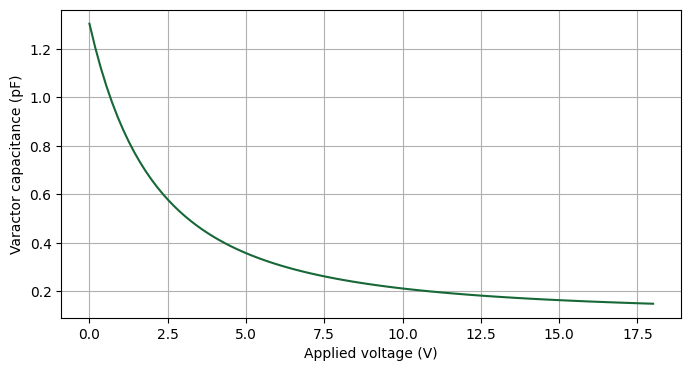

In [7]:
def C_varactor(voltage):
    """Calculate varactor capacitance for given applied voltage (V)"""
    return 1.2e-12 / np.power(1 + voltage / 4.155, 1.97) + 0.1044e-12


fig, ax = plt.subplots(figsize=(8, 4))
voltages = np.linspace(0, 18, 101)
ax.plot(voltages, C_varactor(voltages) / 1e-12)
ax.set_xlabel("Applied voltage (V)")
ax.set_ylabel("Varactor capacitance (pF)")
ax.grid()
plt.show()

Next, we define `create_varactor()` that returns a `LinearLumpedElement` representing the varactor. The `voltage` property represents the applied voltage on the varactor. Note that the varactor also has some innate static resistance `R_load` and inductance `L_load`.

In [8]:
def create_varactor(name, center, axis, voltage):
    """Create a lumped element representing a varactor"""
    # Determine lumped element size
    L_var = stub_gap if axis == 0 else W_stub
    W_var = W_stub if axis == 0 else stub_gap

    # Static varactor parameters
    R_load = 2
    L_load = 0.05e-9

    # Create lumped element
    lumped_element = rf.LinearLumpedElement(
        center=center,
        size=(L_var, W_var, 0),
        name=name,
        voltage_axis=axis,
        network=rf.RLCNetwork(
            resistance=R_load, capacitance=C_varactor(voltage), inductance=L_load
        ),
    )
    return lumped_element

Finally, we put the pieces together to define `create_tuned_antenna_tcm()`. The fields `V1` and `V2` represent the applied voltages on the x-aligned and y-aligned varactors, respectively. Note that each tuning stub is also terminated with a static load given by `R_static` and `L_static`. 

In [9]:
def create_tuned_antenna_tcm(V1, V2):
    """Create TCM simulation corresponding to a varactor-tuned antenna with voltages (V1, V2)."""

    # Iteratively create lumped elements
    varactor_list = []  # Varactor array with (V1, V2)
    static_list = []  # Static elements at end of tuning stubs
    counter = 0  # counter for element naming

    pos1_list = [-stub_spacing, 0, stub_spacing]
    pos2_list = [-L_patch / 2 - stub_gap / 2, L_patch / 2 + stub_gap / 2]
    pos3_list = [-L_patch / 2 - stub_gap - L_stub, L_patch / 2 + stub_gap + L_stub]
    for pos1 in pos1_list:
        for pos2, pos3 in zip(pos2_list, pos3_list):
            counter += 1

            # Create varactors
            le1 = create_varactor(
                name=f"var_x_{counter}", center=(pos2, pos1, 0), axis=0, voltage=V1
            )
            le2 = create_varactor(
                name=f"var_y_{counter}", center=(pos1, pos2, 0), axis=1, voltage=V2
            )
            varactor_list += [le1, le2]

            # Create static circuit
            R_static = 1e6  # 1 MOhm
            L_static = 300e-9  # 300 nH
            le3 = rf.LinearLumpedElement(
                center=(pos3, pos1, -H / 2),
                size=(0, W_stub, H),
                voltage_axis=2,
                name=f"stat_x_{counter}",
                network=rf.RLCNetwork(resistance=R_static, inductance=L_static),
            )
            le4 = le3.updated_copy(
                center=(pos1, pos3, -H / 2),
                size=(W_stub, 0, H),
                name=f"stat_y_{counter}",
            )
            static_list += [le3, le4]

    # Add to base TCM
    base_tcm = create_base_tcm()
    new_tcm = base_tcm.updated_copy(
        simulation=base_tcm.simulation.updated_copy(lumped_elements=varactor_list + static_list)
    )

    return new_tcm

## Visualize Setup

Here, we generate a simulation using `create_tuned_antenna_tcm()` and visualize it.

In [10]:
tcm_visualize = create_tuned_antenna_tcm(4, 4)

The device in the signal and ground planes are shown below, along with the simulation grid. In the signal plane, the dark blue markers represent the varactors as well as the static loads. In the ground plane, the coaxial feed port is visible and shown in green. 

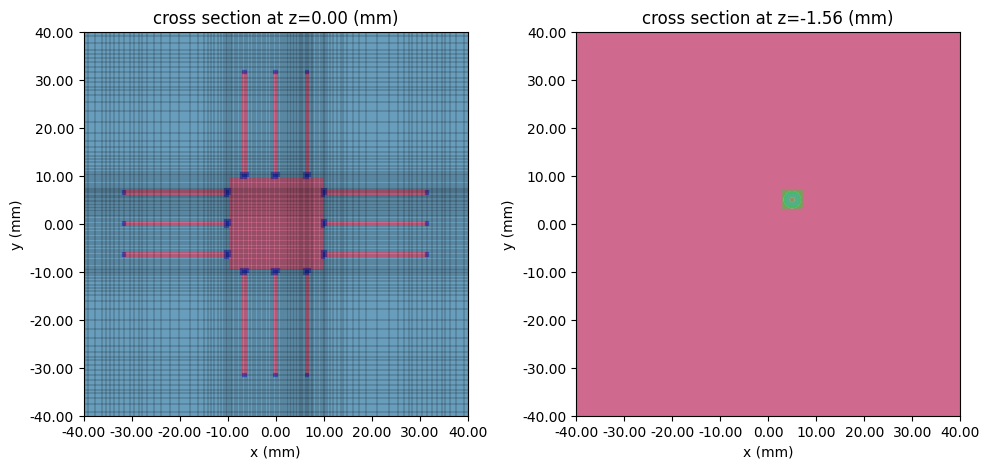

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 10), tight_layout=True)
tcm_visualize.plot_sim(z=0, ax=ax[0])
tcm_visualize.sim_dict["port 1"].plot_grid(z=0, ax=ax[0])
tcm_visualize.plot_sim(z=-H - T, ax=ax[1])

for axis in ax:
    axis.set_xlim(-40 * mm, 40 * mm)
    axis.set_ylim(-40 * mm, 40 * mm)

plt.show()

We can also visualize the simulation in 3D. 

In [12]:
tcm_visualize.simulation.plot_3d()

## Simulating Different Tuning Cases

In this section, we will simulate three sets of (V1, V2) voltage pairs to demonstrate the different modes of operation:
* `tcm_LP90`: (V1, V2) = (0.9, 10) V ---  0/90 degree linear polarization (LP)
* `tcm_LP45`: (V1, V2) = (2.9, 2.9) V --- 45-degree LP,
* `tcm_RHCP`: (V1, V2) = (4, 2.9) V --- Right-handed CP (RHCP)

In [13]:
# Case 1: 0/90deg Linear Polarization
tcm_LP90 = create_tuned_antenna_tcm(0.9, 10)
# Case 2: 45deg Linear Polarization
tcm_LP45 = create_tuned_antenna_tcm(2.9, 2.9)
# Case 3: RH Circular Polarization
tcm_RHCP = create_tuned_antenna_tcm(4, 2.9)

# Build TCM simulation dict
batch_dict = {"LP90": tcm_LP90, "LP45": tcm_LP45, "RHCP": tcm_RHCP}

The batch job is submitted below. 

In [14]:
tcm_data = web.run(batch_dict, task_name="tunable-patch-antenna-sweep-1", path="data")

Output()

16:23:50 EST Started working on Batch containing 3 tasks.

16:23:59 EST Maximum FlexCredit cost: 3.079 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after    
             completion.

Output()

16:29:14 EST Batch complete.

### S-parameter

After the simulation is complete, let us first examine the return loss. 

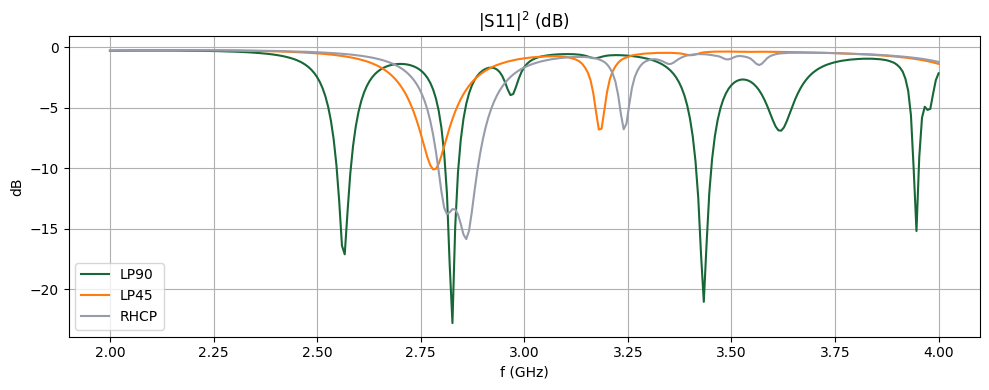

 S11 minima
LP90: -22.80 dB at 2.827 GHz
LP45: -10.09 dB at 2.780 GHz
RHCP: -15.85 dB at 2.860 GHz


In [15]:
fig, ax = plt.subplots(figsize=(10, 4), tight_layout=True)

# Iterate over batch data
S11_freq_minimum = {}
for label, data in tcm_data.items():
    # Extract and plot S11
    smat = data.smatrix()
    S11 = np.conjugate(smat.data.isel(port_in=0, port_out=0).squeeze())
    ax.plot(freqs / 1e9, 20 * np.log10(np.abs(S11)), label=label)
    # Obtain minimum
    S11_freq_minimum[label] = (
        freqs[np.argmin(20 * np.log10(np.abs(S11.data)))],
        np.min(20 * np.log10(np.abs(S11.data))),
    )

ax.set_title("|S11|$^2$ (dB)")
ax.set_xlabel("f (GHz)")
ax.set_ylabel("dB")
ax.grid()
ax.legend()
plt.show()

# Print S11 frequency minimum
print("============\n S11 minima\n============")
for label, data in S11_freq_minimum.items():
    print(f"{label}: {data[1]:.2f} dB at {data[0] / 1e9:.3f} GHz")

All three tuning modes have their primary operating frequency near 2.8 GHz. 

### Axial Ratio

Next, we examine the axial ratio (AR) along the main lobe direction `(theta, phi) = (0, 0)`. An AR value of 1 (or 0 dB) indicates perfect circular polarization. A large value of AR, capped at 100 (or 40 dB) in this plot, indicates linear polarization. 

In [16]:
# Extract radiation data
AM = {key: data.get_antenna_metrics_data() for key, data in tcm_data.items()}
# Plotting frequencies
plot_freqs = {"LP90": 2.825e9, "LP45": 2.785e9, "RHCP": 2.82e9}

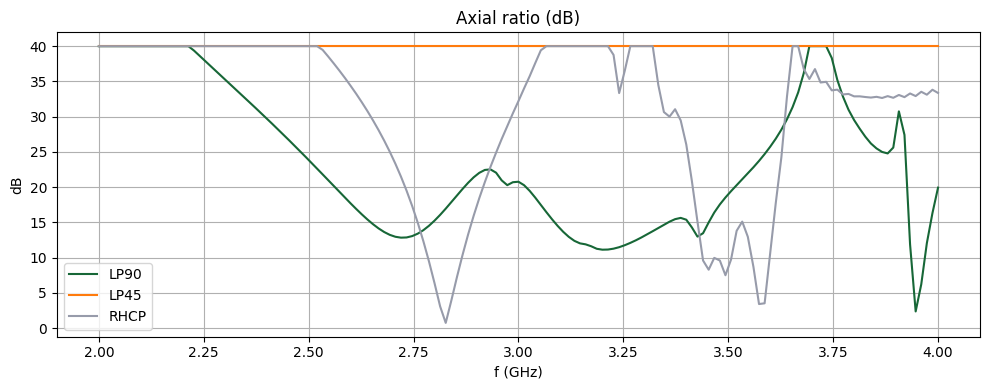

In [17]:
# Plot main lobe axial ratio at S11 minima
fig, ax = plt.subplots(figsize=(10, 4), tight_layout=True)

for label, data in AM.items():
    AR = data.axial_ratio
    ar_plot = AR.sel(phi=0, theta=0, method="nearest").squeeze()
    ax.plot(ar_plot.f / 1e9, 20 * np.log10(ar_plot), label=label)

ax.grid()
ax.set_title("Axial ratio (dB)")
ax.set_xlabel("f (GHz)")
ax.set_ylabel("dB")
ax.legend()
plt.show()

### Antenna Gain

Next, we examine the radiation gain pattern at the operating frequency. 

The `plot_partial_gain_elevation()` function defined below extracts the partial gain from the antenna metrics dataset, splits it by polarization basis (theta/phi if LP; right/left if CP), and plots the partial gain for each polarization separately. Both the E- and H-planes are shown. 

In [18]:
def plot_partial_gain_elevation(AM_dataset, plot_freq, pol_basis, ax):
    """Plots partial gains for given dataset label and polarization basis"""
    pgain = AM_dataset.partial_gain(pol_basis=pol_basis).sel(f=plot_freq, method="nearest")
    if pol_basis == "linear":
        pgain_pol1 = pgain.Gtheta
        pgain_pol2 = pgain.Gphi
        plot_labels = ["Theta-polarized", "Phi-polarized"]
    else:
        pgain_pol1 = pgain.Gright
        pgain_pol2 = pgain.Gleft
        plot_labels = ["Right circular", "Left circular"]

    # Plot gain for phi =0
    gplot = pgain_pol1.sel(phi=0, method="nearest").squeeze()
    ax[0].plot(theta, 10 * np.log10(gplot), "r", label=plot_labels[0])
    gplot = pgain_pol1.sel(phi=np.pi, method="nearest").squeeze()
    ax[0].plot(-theta, 10 * np.log10(gplot), "r")
    gplot = pgain_pol2.sel(phi=0, method="nearest").squeeze()
    ax[0].plot(theta, 10 * np.log10(gplot), "r--", label=plot_labels[1])
    gplot = pgain_pol2.sel(phi=np.pi, method="nearest").squeeze()
    ax[0].plot(-theta, 10 * np.log10(gplot), "r--")
    ax[0].set_title("Partial Gain (dB) in elevation plane ($\\phi=0$ deg)", pad=30)

    # Plot gain for phi =0
    gplot = pgain_pol1.sel(phi=np.pi / 2, method="nearest").squeeze()
    ax[1].plot(theta, 10 * np.log10(gplot), "b", label=plot_labels[0])
    gplot = pgain_pol1.sel(phi=3 * np.pi / 2, method="nearest").squeeze()
    ax[1].plot(-theta, 10 * np.log10(gplot), "b")
    gplot = pgain_pol2.sel(phi=np.pi / 2, method="nearest").squeeze()
    ax[1].plot(theta, 10 * np.log10(gplot), "b--", label=plot_labels[1])
    gplot = pgain_pol2.sel(phi=3 * np.pi / 2, method="nearest").squeeze()
    ax[1].plot(-theta, 10 * np.log10(gplot), "b--")
    ax[1].set_title("Gain (dB) in elevation plane ($\\phi=90$ deg)", pad=30)

    for axis in ax:
        axis.set_theta_direction(-1)
        axis.set_theta_offset(np.pi / 2.0)
        axis.legend()

First, the pattern for the `tcm_LP45` tuning mode. Notice that both linear basis polarizations contribute roughly equal gain along the main lobe (`theta = 0`). 

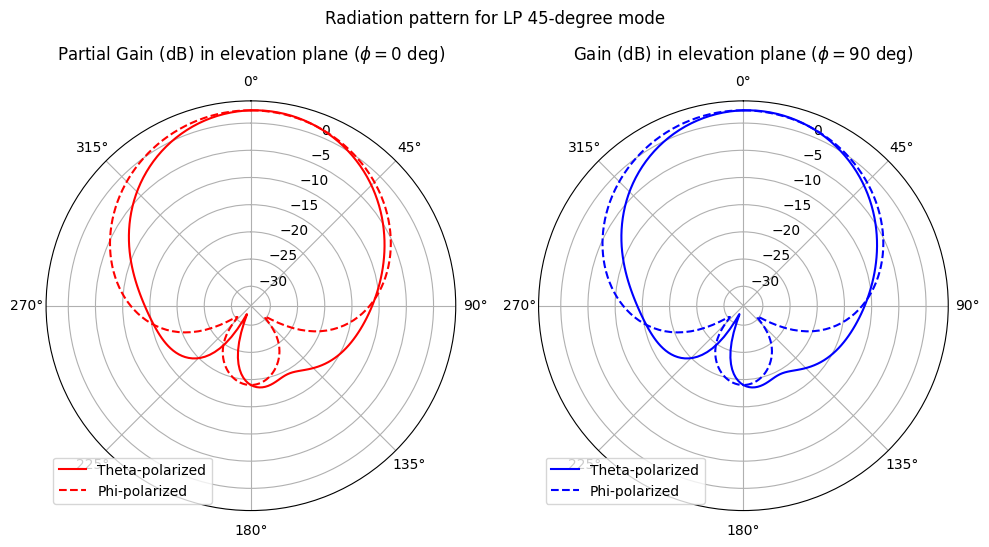

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(10, 8), tight_layout=True, subplot_kw={"projection": "polar"})
plot_partial_gain_elevation(AM["LP45"], plot_freqs["LP45"], "linear", ax=ax)
fig.suptitle("Radiation pattern for LP 45-degree mode", y=0.85)
plt.show()

In the `tcm_LP90` operation mode, only one polarization direction contributes significant gain. Note that the co-polarized basis vector (theta or phi direction) switches depending whether we are plotting the E- or H-planes. 

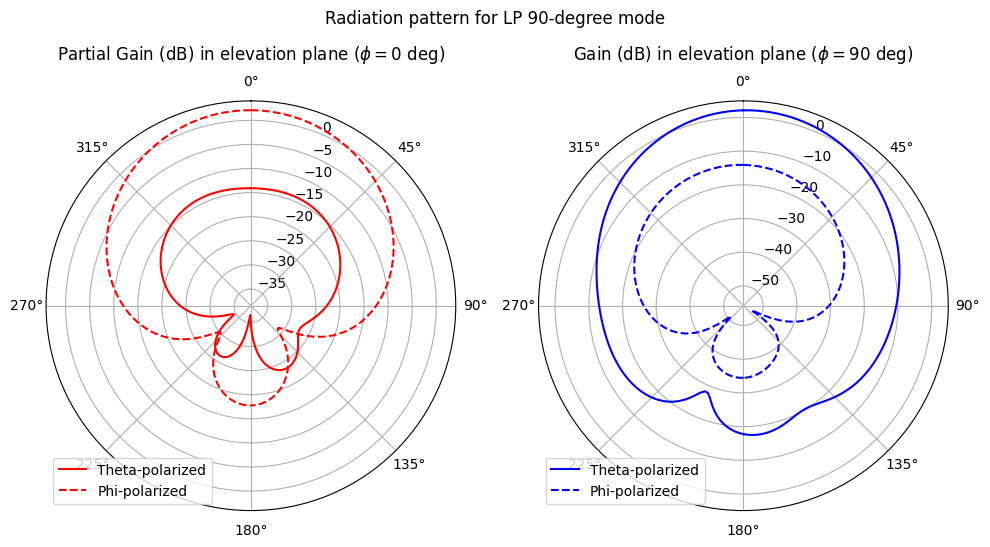

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(10, 8), tight_layout=True, subplot_kw={"projection": "polar"})
plot_partial_gain_elevation(AM["LP90"], plot_freqs["LP90"], "linear", ax=ax)
fig.suptitle("Radiation pattern for LP 90-degree mode", y=0.85)
plt.show()

In the `tcm_RHCP` operation mode, the RHCP is the dominant mode, as expected.

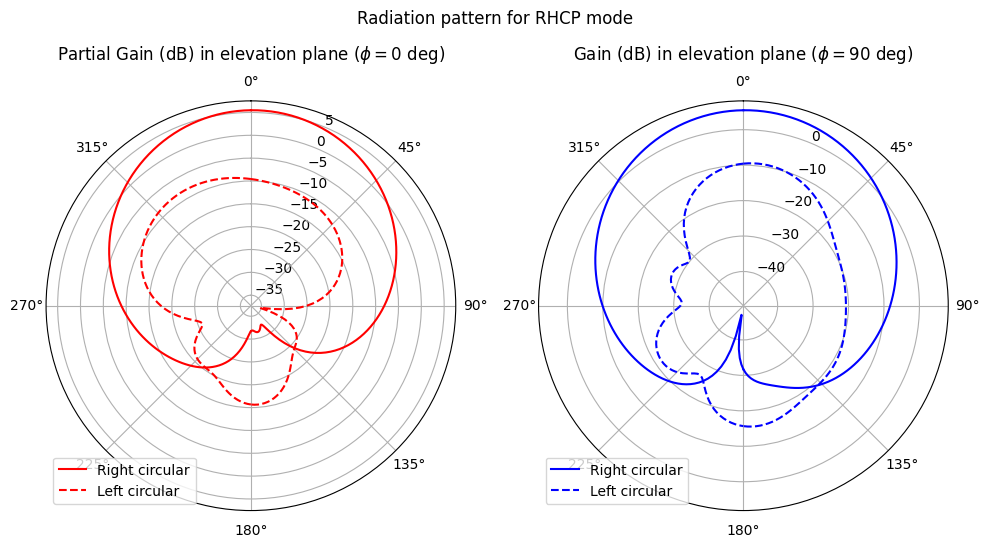

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(10, 8), tight_layout=True, subplot_kw={"projection": "polar"})
plot_partial_gain_elevation(AM["RHCP"], plot_freqs["RHCP"], "circular", ax=ax)
fig.suptitle("Radiation pattern for RHCP mode", y=0.85)
plt.show()

### Polarization Ellipse

Here, we demonstrate how to plot the polarization ellipse of the radiated field. First, we define the utility function `plot_polarization_ellipse()` that plots an ellipse of given parameters. 

In [22]:
def plot_polarization_ellipse(ax, psi, chi, color, label, intensity=1.0):
    """Plots the polarization ellipse given the orientation angle psi (rad) and the ellipticity angle chi (rad)."""
    # Calculate major and minor axis, a and b
    a = np.sqrt(intensity) * np.cos(chi)
    b = np.sqrt(intensity) * np.sin(chi)

    # Ensure a is always the semi-major axis (a >= b)
    if np.abs(a) < np.abs(b):
        a, b = b, a

    # Define parametric equation/coordinates for unrotated ellipse
    t = np.linspace(0, 2 * np.pi, 201)
    x_prime = a * np.cos(t)
    y_prime = b * np.sin(t)

    # Apply rotation by orientation angle
    x = x_prime * np.cos(psi) - y_prime * np.sin(psi)
    y = x_prime * np.sin(psi) + y_prime * np.cos(psi)

    # Draw handedness arrow
    arrow_start = (x[0], y[0])
    arrow_end = (x[8], y[8])
    ax.annotate(
        "",
        xytext=arrow_start,
        xy=arrow_end,
        arrowprops=dict(arrowstyle=ArrowStyle("Wedge", tail_width=1.5), fc=color, color=color),
    )

    # Make plot
    ax.plot(x, y, label=label, color=color)

The polarization ellipse parameters can be derived from the Stokes parameters. These, in turn, can be calculated from the `E_right` and `E_left` components of the far-field radiation. We calculate and plot the polarization ellipse below. 

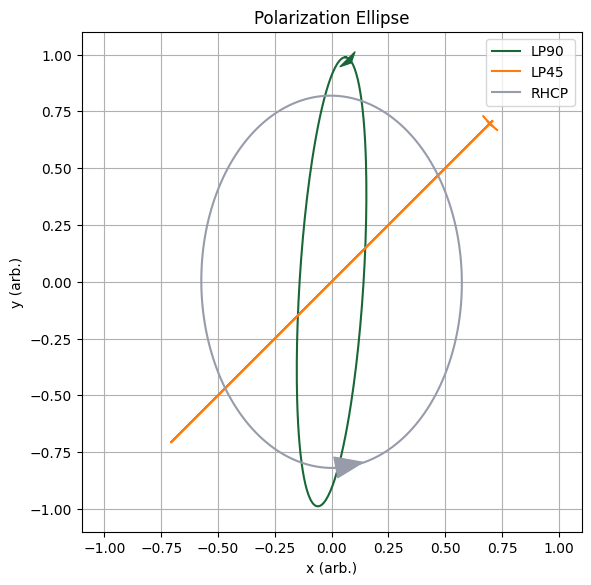

In [23]:
fig, ax = plt.subplots(figsize=(6, 6), tight_layout=True)
plot_colors = {"LP90": "C0", "LP45": "C1", "RHCP": "C2"}

for label, data in AM.items():
    # Extract E_left, E_right
    E_left = data.left_polarization
    E_right = data.right_polarization

    # Calculate Stokes parameters from E_left and E_right
    phase_diff = np.angle(E_left) - np.angle(E_right)
    S0 = np.abs(E_left) ** 2 + np.abs(E_right) ** 2
    S1 = 2 * np.abs(E_right) * np.abs(E_left) * np.cos(phase_diff)
    S2 = 2 * np.abs(E_right) * np.abs(E_left) * np.sin(phase_diff)
    S3 = np.abs(E_right) ** 2 - np.abs(E_left) ** 2

    # Calculate polarization ellipse angles
    pol_chi = 0.5 * np.asin(S3 / S0)  # Ellipticity angle
    pol_psi = 0.5 * np.atan2(S2, S1)  # Orientation angle

    # Select data for plotting
    chi_plot = pol_chi.sel(f=plot_freqs[label], theta=0, phi=0, method="nearest").data[0]
    psi_plot = pol_psi.sel(f=plot_freqs[label], theta=0, phi=0, method="nearest").data[0]

    # Plot ellipse
    plot_polarization_ellipse(
        ax=ax, psi=psi_plot, chi=chi_plot, intensity=1.0, color=plot_colors[label], label=label
    )


ax.set_title("Polarization Ellipse")
ax.set_xlabel("x (arb.)")
ax.set_ylabel("y (arb.)")
ax.set_aspect(1)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.grid()
ax.legend()
plt.show()

## Generating Tuning Map

To generate a full tuning map for this antenna design, it is necessary to sweep the `(V1, V2)` parameters. Below, we sweep each voltage between 0 and 10 V, and generate the associated batch simulation `dict`. The spacing between each voltage point is chosen to provide approximately uniform coverage in the varactor capacitance tuning space. 

**Warning**: The batch simulation demonstrated in this section is very large and will cost a large amount of FlexCredits to execute. 

In [24]:
# Generate voltage sweep values
V1_list = np.array([10, 7, 5, 4, 2.9, 2.5, 2, 1.4, 0.9, 0.5, 0.25, 0])
V2_list = V1_list
batch_map_dict = {}
for V1 in V1_list:
    for V2 in V2_list:
        batch_map_dict[(V1, V2)] = create_tuned_antenna_tcm(V1, V2)

The sampled capacitance points by the sweep are indicated in the scatter plot below. 

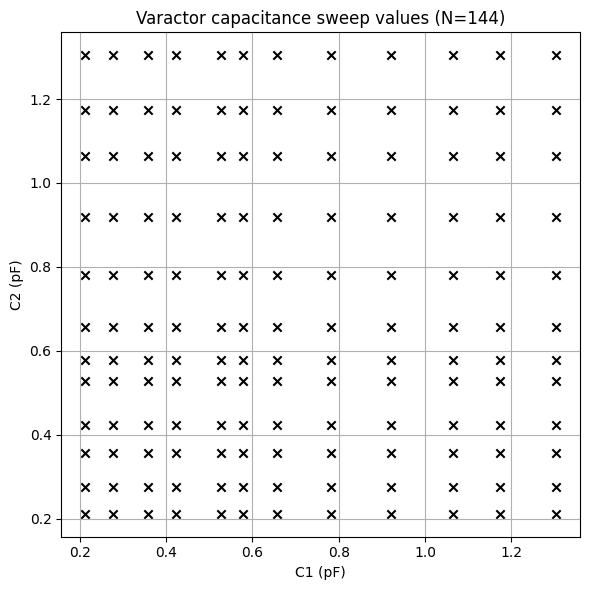

In [25]:
fig, ax = plt.subplots(figsize=(6, 6), tight_layout=True)
for label, tcm in batch_map_dict.items():
    ax.scatter(
        C_varactor(label[0]) / 1e-12, C_varactor(label[1]) / 1e-12, color="black", marker="x"
    )
ax.grid()
ax.set_title(f"Varactor capacitance sweep values (N={len(batch_map_dict)})")
ax.set_xlabel("C1 (pF)")
ax.set_ylabel("C2 (pF)")
plt.show()

The batch simulation is submitted below. 

In [26]:
# Submit batch run
tcm_data_map = web.run(batch_map_dict, task_name="tuned_patch_antenna_map", path="data")

Output()

16:32:47 EST Started working on Batch containing 144 tasks.

16:35:56 EST Maximum FlexCredit cost: 147.772 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after    
             completion.

Output()

17:28:57 EST Batch complete.

### S-parameter Mode Map

After the batch run is completed, we gather all the S-parameter data into a single `xarray` object. Appropriate coordinates are introduced for the `V1` and `V2` parameters. 

In [27]:
# Gather S11(V1, V2) into single Xarray data object
S11_temp = [
    data.smatrix().data.expand_dims(V1=[v1], V2=[v2]) for (v1, v2), data in tcm_data_map.items()
]
S11_map = xarray.combine_by_coords(S11_temp)
S11dB_map = 20 * np.log10(np.abs(S11_map))

The S-parameter mode maps are plotted below. For given values of `V1`, the S11 (dB) is plotted with `V2` and `f` as the dependent variables. The light-colored bands indicate resonances (fundamental and higher-order) which shift as the tuning voltages are changed. 

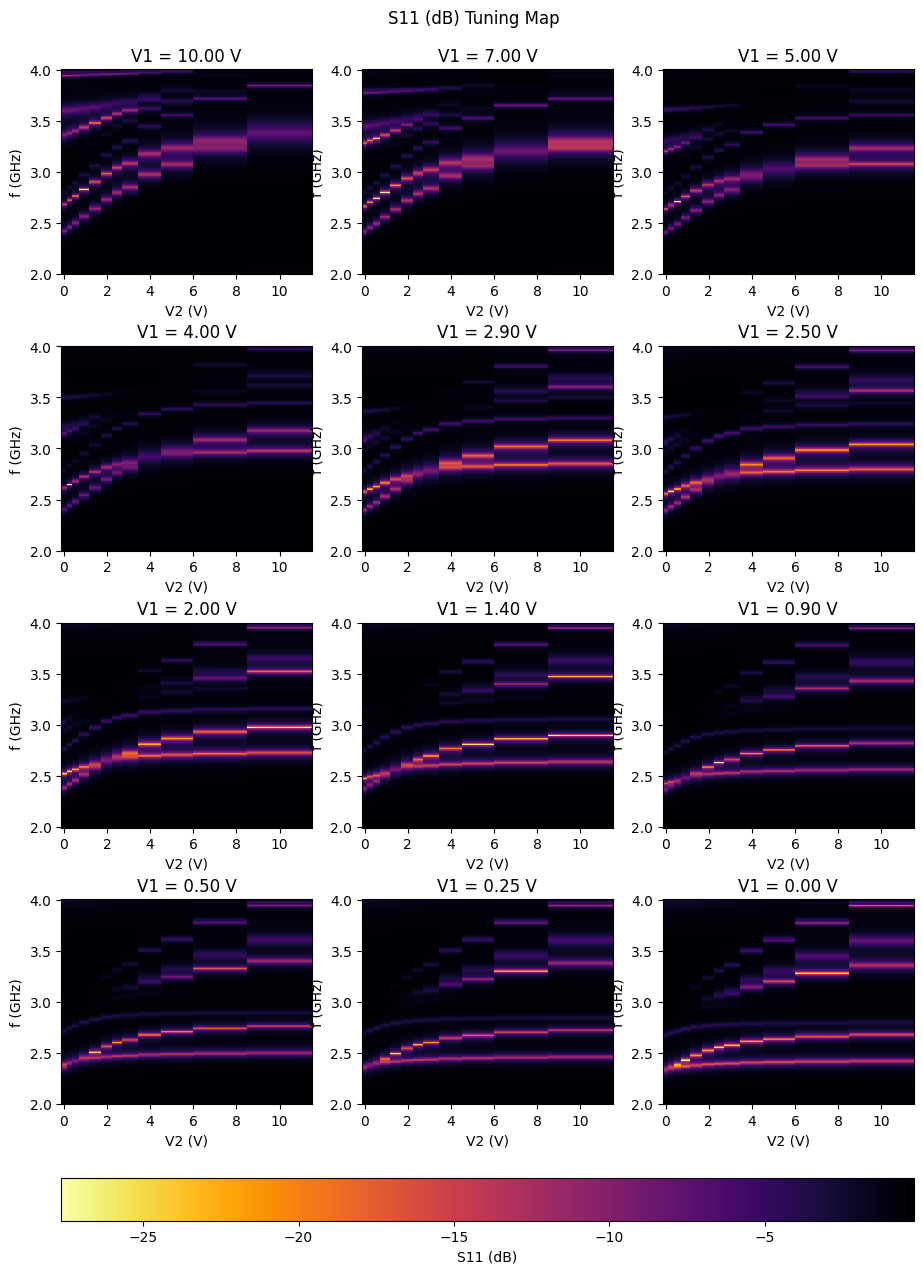

In [28]:
# For certain values of V1, plot S11 (dB) for (x, y) = (C2, f)
V1_plot = V1_list
fig, ax = plt.subplots(len(V1_plot) // 3, 3, figsize=(11, 15))
for ii, V1 in enumerate(V1_plot):
    pcm = ax[ii // 3, ii % 3].pcolormesh(
        S11dB_map.V2,
        S11dB_map.f / 1e9,
        20 * np.log10(np.abs(S11_map.sel(V1=V1))).squeeze().T,
        shading="nearest",
        cmap="inferno_r",
    )
    ax[ii // 3, ii % 3].set_title(f"V1 = {V1:.2f} V")
    ax[ii // 3, ii % 3].set_xlabel("V2 (V)")
    ax[ii // 3, ii % 3].set_ylabel("f (GHz)")

cbar = fig.colorbar(
    pcm, ax=ax.ravel().tolist(), orientation="horizontal", label="S11 (dB)", fraction=0.04, pad=0.06
)
plt.subplots_adjust(hspace=0.35, bottom=0.19)
# fig.supxlabel('Varactor capacitance C2 (pF)', y=0.03)
# fig.supylabel('Frequency (GHz)', x=0.07)
fig.suptitle("S11 (dB) Tuning Map", y=0.92, x=0.5)
plt.show()

### Polarization Tuning Map

At the fundamental resonance, we would also like to assess the polarization of the radiated far-field. One way to accomplish this is to plot the axial ratio, while filtering by S11 < -10 dB to isolate the resonant tuning regions. 

In [29]:
# Gather AR(V1, V2) into single Xarray object
AR_temp = [
    data.get_antenna_metrics_data().axial_ratio.expand_dims(V1=[v1], V2=[v2])
    for (v1, v2), data in tcm_data_map.items()
]
AR_map = xarray.combine_by_coords(AR_temp).sel(theta=0, phi=0, method="nearest")
AR_map_filtered = AR_map.where(S11dB_map < -10)

Below, red color indicates tuning regions with strong LP, whereas blue color indicates those with strong CP. 

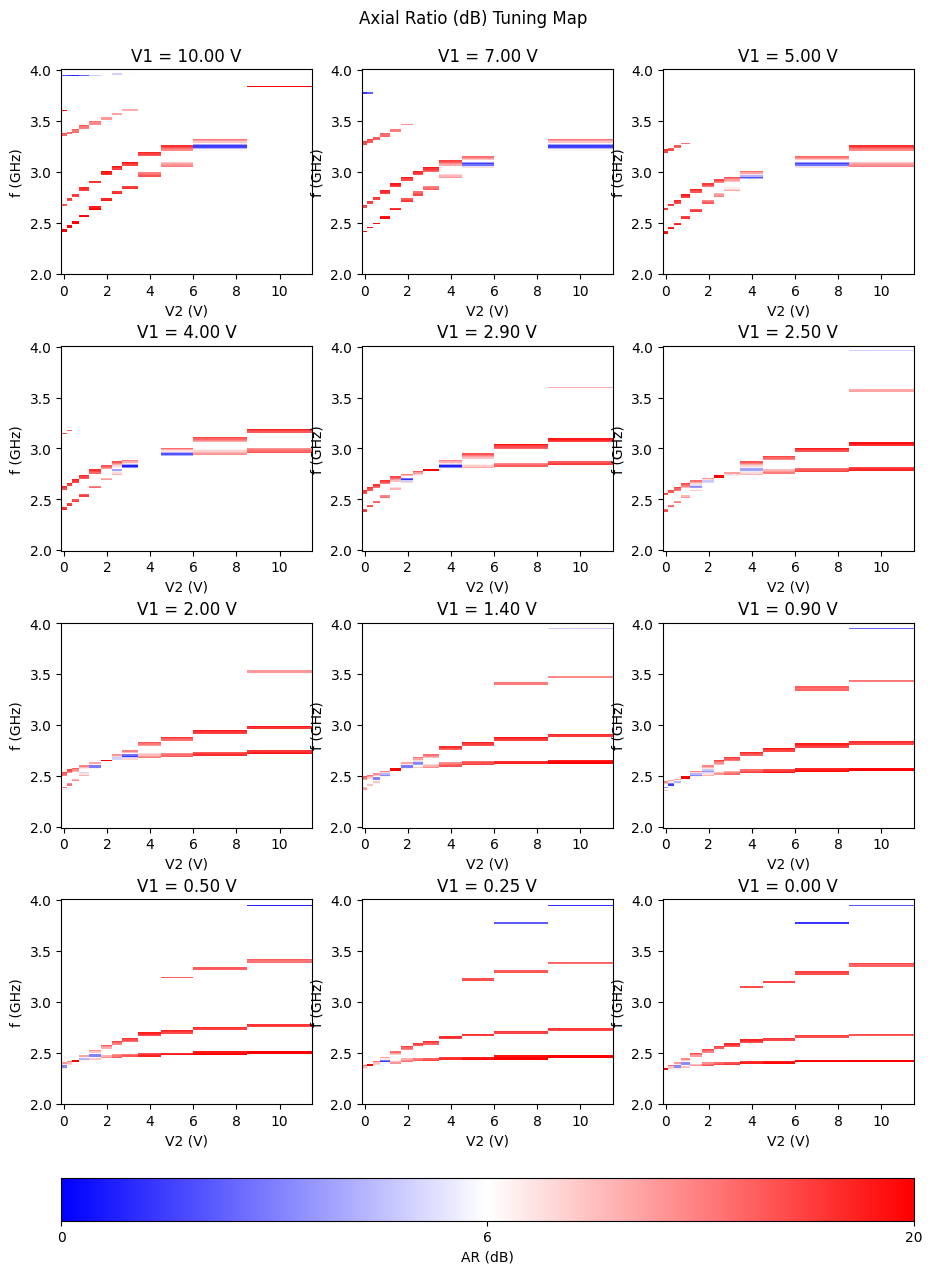

In [30]:
# For certain values of V1, plot AR (dB) for (x, y) = (C2, f)
V1_plot = V1_list[::]
fig, ax = plt.subplots(len(V1_plot) // 3, 3, figsize=(11, 15))
norm = TwoSlopeNorm(vmin=0, vcenter=6, vmax=20)
for ii, V1 in enumerate(V1_plot):
    pcm = ax[ii // 3, ii % 3].pcolormesh(
        AR_map_filtered.V2,
        AR_map_filtered.f / 1e9,
        20 * np.log10(np.abs(AR_map_filtered)).sel(V1=V1).squeeze().T,
        shading="nearest",
        cmap="bwr",
        norm=norm,
    )
    ax[ii // 3, ii % 3].set_title(f"V1 = {V1:.2f} V")
    ax[ii // 3, ii % 3].set_xlabel("V2 (V)")
    ax[ii // 3, ii % 3].set_ylabel("f (GHz)")

cbar = fig.colorbar(
    pcm,
    ax=ax.ravel().tolist(),
    orientation="horizontal",
    label="AR (dB)",
    fraction=0.04,
    pad=0.06,
    ticks=[0, 6, 20],
)
plt.subplots_adjust(hspace=0.35, bottom=0.19)
# fig.supxlabel('Varactor capacitance C2 (pF)', y=0.03)
# fig.supylabel('Frequency (GHz)', x=0.07)
fig.suptitle("Axial Ratio (dB) Tuning Map", y=0.92, x=0.5)
plt.show()

## Reference

[1] Nguyen-Trong, Nghia, Leonard Hall, and Christophe Fumeaux. "A frequency-and polarization-reconfigurable stub-loaded microstrip patch antenna." IEEE transactions on antennas and propagation 63, no. 11 (2015): 5235-5240.